# 10 - Probabilistic Framework

This notebook adds Gaussian, Multinomial and Bernoulli Naive Bayes models plus Bayesian Linear Regression. EnergyTypeNet remains the primary dataset. Supplementary sklearn datasets are used only where the model assumptions require a different data structure.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.datasets import fetch_20newsgroups, fetch_california_housing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.preprocessing import Binarizer, StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

from src.models import (
    BayesianLinearRegression,
    BernoulliNaiveBayes,
    GaussianNaiveBayes,
    LogisticRegressionOvR,
    MultinomialNaiveBayes,
)

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## 1. Bayes' Theorem - Visual Derivation

Bayes' theorem states:

$$P(C \mid X) = \frac{P(X \mid C)P(C)}{P(X)}$$

- `P(X | C)` is the likelihood.
- `P(C)` is the prior.
- `P(X)` is the evidence.
- `P(C | X)` is the posterior.

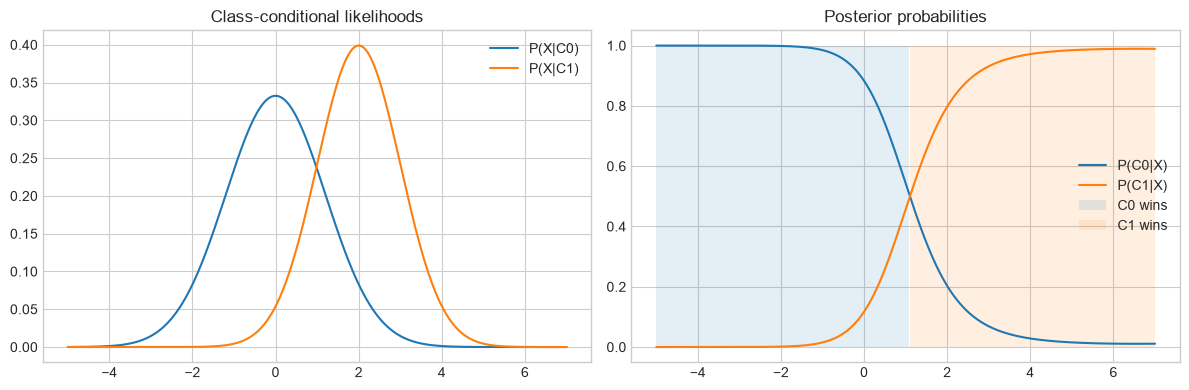

In [2]:
x = np.linspace(-5, 7, 500)
prior_0, prior_1 = 0.55, 0.45
like_0 = np.exp(-0.5 * ((x - 0.0) / 1.2) ** 2) / (1.2 * np.sqrt(2 * np.pi))
like_1 = np.exp(-0.5 * ((x - 2.0) / 1.0) ** 2) / (1.0 * np.sqrt(2 * np.pi))
evidence = prior_0 * like_0 + prior_1 * like_1
post_0 = prior_0 * like_0 / evidence
post_1 = prior_1 * like_1 / evidence

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, like_0, label='P(X|C0)')
axes[0].plot(x, like_1, label='P(X|C1)')
axes[0].set_title('Class-conditional likelihoods')
axes[0].legend()

axes[1].plot(x, post_0, label='P(C0|X)')
axes[1].plot(x, post_1, label='P(C1|X)')
axes[1].fill_between(x, 0, 1, where=post_0 >= post_1, alpha=0.12, label='C0 wins')
axes[1].fill_between(x, 0, 1, where=post_1 > post_0, alpha=0.12, label='C1 wins')
axes[1].set_title('Posterior probabilities')
axes[1].legend()
plt.tight_layout()

## 2. GaussianNaiveBayes on EnergyTypeNet

Gaussian Naive Bayes models each numeric feature as normally distributed within each class.

In [3]:
train_df = pd.read_csv(ROOT / 'data' / 'train_energy_data.csv').dropna()
test_df = pd.read_csv(ROOT / 'data' / 'test_energy_data.csv').dropna()

feature_cols = ['Energy Consumption', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
class_names = ['Residential', 'Commercial', 'Industrial']
label_map = {name: idx for idx, name in enumerate(class_names)}

X_train = train_df[feature_cols].to_numpy(float)
X_test = test_df[feature_cols].to_numpy(float)
y_train = train_df['Building Type'].map(label_map).to_numpy()
y_test = test_df['Building Type'].map(label_map).to_numpy()

custom_gnb = GaussianNaiveBayes().fit(X_train, y_train)
sklearn_gnb = GaussianNB().fit(X_train, y_train)

custom_pred = custom_gnb.predict(X_test)
sklearn_pred = sklearn_gnb.predict(X_test)
custom_acc = accuracy_score(y_test, custom_pred)
sklearn_acc = accuracy_score(y_test, sklearn_pred)
assert abs(custom_acc - sklearn_acc) <= 0.03

pd.DataFrame([
    {'model': 'Custom GaussianNaiveBayes', 'accuracy': custom_acc},
    {'model': 'sklearn GaussianNB', 'accuracy': sklearn_acc},
])

,model,accuracy
0,Custom GaussianNaiveBayes,0.42
1,sklearn GaussianNB,0.42


In [4]:
print('Confusion matrix:')
print(confusion_matrix(y_test, custom_pred))
print('\nClassification report:')
print(classification_report(y_test, custom_pred, target_names=class_names))

priors = pd.DataFrame({'class': class_names, 'prior': custom_gnb.class_priors_})
means = pd.DataFrame(custom_gnb.means_, columns=feature_cols, index=class_names)
display(priors)
display(means)

Confusion matrix:
[[21 11  8]
 [ 7  5 14]
 [ 5 13 16]]

Classification report:
              precision    recall  f1-score   support

 Residential       0.64      0.53      0.58        40
  Commercial       0.17      0.19      0.18        26
  Industrial       0.42      0.47      0.44        34

    accuracy                           0.42       100
   macro avg       0.41      0.40      0.40       100
weighted avg       0.44      0.42      0.43       100



,class,prior
0,Residential,0.347
1,Commercial,0.336
2,Industrial,0.317


,Energy Consumption,Square Footage,Number of Occupants,Appliances Used,Average Temperature
Residential,3681.626628,25825.613833,47.726225,25.051873,22.864496
Commercial,4130.023571,24386.553571,47.880952,25.901786,22.200119
Industrial,4735.142618,26205.104101,49.599369,25.899054,22.770252


## 3. Feature Distributions per Class

The Gaussian assumption is more plausible when each class-specific feature distribution is roughly symmetric and single-peaked. The plots below use a small hand-written Gaussian KDE so the notebook does not depend on extra plotting packages.

,feature,skewness,note
0,Energy Consumption,-0.046241,approximately Gaussian
1,Square Footage,0.009313,approximately Gaussian
2,Number of Occupants,0.089302,approximately Gaussian
3,Appliances Used,-0.037392,approximately Gaussian
4,Average Temperature,-0.040406,approximately Gaussian


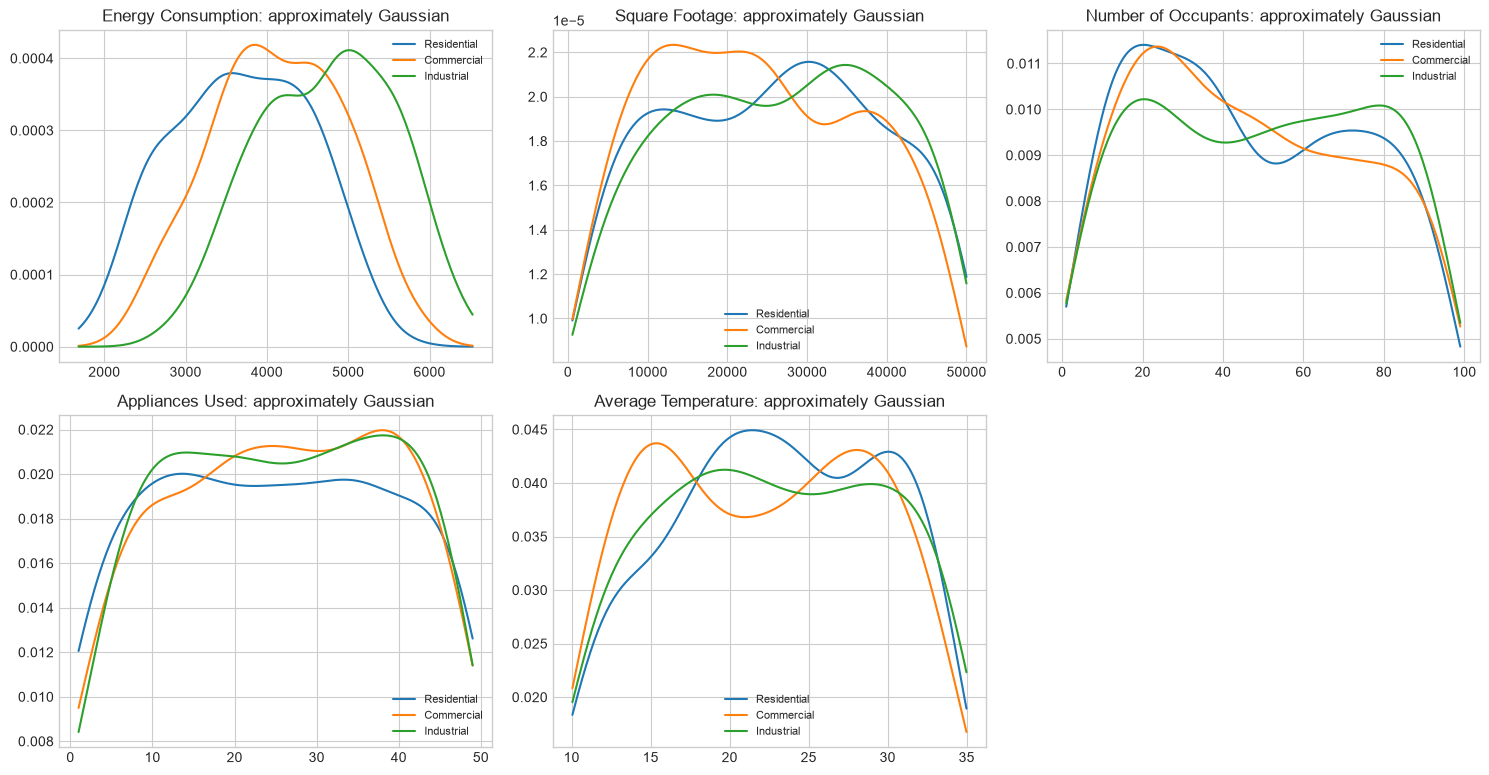

In [5]:
def simple_kde(values, grid):
    values = np.asarray(values, dtype=float)
    std = values.std(ddof=1)
    bandwidth = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 1.0
    bandwidth = max(bandwidth, 1e-6)
    scaled = (grid[:, None] - values[None, :]) / bandwidth
    return np.exp(-0.5 * scaled ** 2).mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
distribution_notes = []
for ax, feature in zip(axes, feature_cols):
    grid = np.linspace(train_df[feature].min(), train_df[feature].max(), 200)
    for class_name in class_names:
        values = train_df.loc[train_df['Building Type'] == class_name, feature]
        ax.plot(grid, simple_kde(values, grid), label=class_name)
    skewness = train_df[feature].skew()
    note = 'approximately Gaussian' if abs(skewness) < 0.5 else 'skewed'
    distribution_notes.append({'feature': feature, 'skewness': skewness, 'note': note})
    ax.set_title(f'{feature}: {note}')
    ax.legend(fontsize=8)

for ax in axes[len(feature_cols):]:
    ax.axis('off')
plt.tight_layout()
pd.DataFrame(distribution_notes)

## 4. Independence Assumption Check

Naive Bayes assumes conditional independence between features given the class. Correlated features violate that assumption, but the model can still work well in practice.

,Energy Consumption,Square Footage,Number of Occupants,Appliances Used,Average Temperature
Energy Consumption,1.000000,0.774873,0.354485,0.312792,-0.034487
Square Footage,0.774873,1.000000,0.033379,-0.013478,0.027273
Number of Occupants,0.354485,0.033379,1.000000,0.023646,0.014122
Appliances Used,0.312792,-0.013478,0.023646,1.000000,-0.062870
Average Temperature,-0.034487,0.027273,0.014122,-0.062870,1.000000


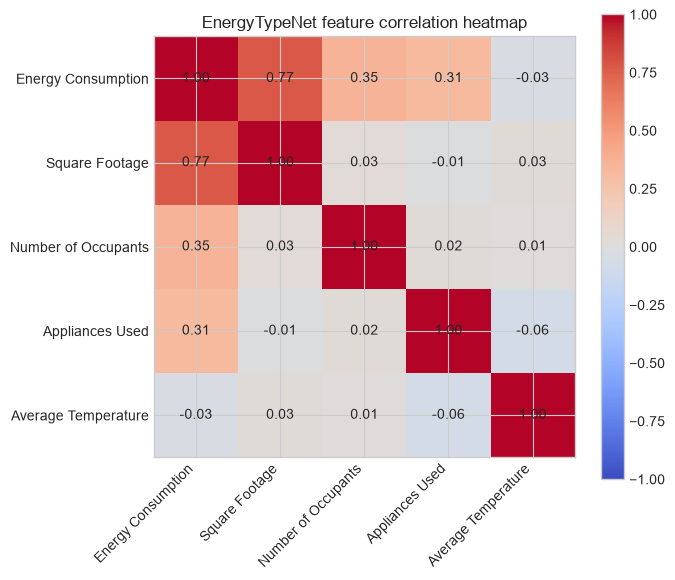

In [6]:
corr = train_df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_yticklabels(feature_cols)
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=ax)
ax.set_title('EnergyTypeNet feature correlation heatmap')
plt.tight_layout()
corr

## 5. MultinomialNaiveBayes on 20 Newsgroups

Multinomial Naive Bayes requires non-negative count features. EnergyTypeNet has continuous numeric features, so text word counts are the valid demonstration domain. This section runs only when 20 Newsgroups is already cached locally.

In [7]:
categories = ['sci.med', 'sci.space', 'talk.religion.misc', 'comp.graphics']
newsgroups_available = False
try:
    news_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'), download_if_missing=False)
    news_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'), download_if_missing=False)
    vectorizer = CountVectorizer(max_features=5000, stop_words='english')
    X_news_train = vectorizer.fit_transform(news_train.data).toarray()
    X_news_test = vectorizer.transform(news_test.data).toarray()
    y_news_train = news_train.target
    y_news_test = news_test.target
    custom_mnb = MultinomialNaiveBayes(alpha=1.0).fit(X_news_train, y_news_train)
    sklearn_mnb = MultinomialNB(alpha=1.0).fit(X_news_train, y_news_train)
    custom_news_acc = accuracy_score(y_news_test, custom_mnb.predict(X_news_test))
    sklearn_news_acc = accuracy_score(y_news_test, sklearn_mnb.predict(X_news_test))
    assert abs(custom_news_acc - sklearn_news_acc) <= 0.02
    newsgroups_available = True
    news_results = pd.DataFrame([
        {'model': 'Custom MultinomialNaiveBayes', 'accuracy': custom_news_acc},
        {'model': 'sklearn MultinomialNB', 'accuracy': sklearn_news_acc},
    ])
except OSError as exc:
    news_results = pd.DataFrame([{'model': '20 Newsgroups skipped', 'accuracy': np.nan, 'note': str(exc)}])

news_results

,model,accuracy,note
0,20 Newsgroups skipped,NaN,20Newsgroups dataset not found


In [8]:
if newsgroups_available:
    vocab = np.array(vectorizer.get_feature_names_out())
    top_words = {}
    for class_idx, class_name in enumerate(news_train.target_names):
        top_idx = np.argsort(custom_mnb.feature_log_prob_[class_idx])[-15:][::-1]
        top_words[class_name] = ', '.join(vocab[top_idx])
    display(pd.DataFrame({'class': top_words.keys(), 'top_words': top_words.values()}))
else:
    print('20 Newsgroups is not cached locally, so the text-only MultinomialNB demonstration was skipped.')

20 Newsgroups is not cached locally, so the text-only MultinomialNB demonstration was skipped.


Laplace smoothing adds `alpha` pseudo-counts so unseen words do not receive zero probability. This matters most for rare words and small class-specific vocabularies.

## 6. BernoulliNaiveBayes on EnergyTypeNet

Bernoulli Naive Bayes treats features as binary events. For EnergyTypeNet, numeric features are binarized at their training-set median.

In [9]:
medians = np.median(X_train, axis=0)
X_train_bin = (X_train > medians).astype(float)
X_test_bin = (X_test > medians).astype(float)

custom_bnb = BernoulliNaiveBayes(alpha=1.0, binarize=None).fit(X_train_bin, y_train)
sklearn_bnb = BernoulliNB(alpha=1.0, binarize=None).fit(X_train_bin, y_train)

bnb_results = pd.DataFrame([
    {'model': 'Custom BernoulliNaiveBayes', 'accuracy': accuracy_score(y_test, custom_bnb.predict(X_test_bin))},
    {'model': 'sklearn BernoulliNB', 'accuracy': accuracy_score(y_test, sklearn_bnb.predict(X_test_bin))},
])
bnb_results

,model,accuracy
0,Custom BernoulliNaiveBayes,0.47
1,sklearn BernoulliNB,0.47


Binarization can be useful when the event itself matters, such as whether a feature is above a meaningful threshold. It discards magnitude information, so it is usually less expressive for continuous engineering measurements.

## 7. BayesianLinearRegression

Bayesian linear regression returns both predictive means and uncertainty estimates. EnergyTypeNet is used first; California Housing is optional and runs only if cached locally.

In [10]:
reg_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
Xr_train = train_df[reg_features].to_numpy(float)
yr_train = train_df['Energy Consumption'].to_numpy(float)
Xr_test = test_df[reg_features].to_numpy(float)
yr_test = test_df['Energy Consumption'].to_numpy(float)

x_scaler = StandardScaler().fit(Xr_train)
Xr_train_s = x_scaler.transform(Xr_train)
Xr_test_s = x_scaler.transform(Xr_test)

custom_blr = BayesianLinearRegression(alpha=1.0, beta=1.0).fit(Xr_train_s, yr_train)
blr_mean, blr_var = custom_blr.predict(Xr_test_s)
sklearn_br = BayesianRidge().fit(Xr_train_s, yr_train)
sklearn_mean = sklearn_br.predict(Xr_test_s)

energy_blr_results = pd.DataFrame([
    {'model': 'Custom BayesianLinearRegression', 'mse': mean_squared_error(yr_test, blr_mean), 'r2': r2_score(yr_test, blr_mean), 'mean_predictive_variance': blr_var.mean()},
    {'model': 'sklearn BayesianRidge', 'mse': mean_squared_error(yr_test, sklearn_mean), 'r2': r2_score(yr_test, sklearn_mean), 'mean_predictive_variance': np.nan},
])
energy_blr_results

,model,mse,r2,mean_predictive_variance
0,Custom BayesianLinearRegression,184574.586552,0.731029,1.004921
1,sklearn BayesianRidge,184719.156987,0.730818,NaN


In [11]:
california_available = False
try:
    housing = fetch_california_housing(download_if_missing=False)
    Xh_train, Xh_test, yh_train, yh_test = train_test_split(housing.data, housing.target, test_size=0.25, random_state=RANDOM_STATE)
    h_scaler = StandardScaler().fit(Xh_train)
    Xh_train_s = h_scaler.transform(Xh_train)
    Xh_test_s = h_scaler.transform(Xh_test)
    settings = [(1, 1), (0.01, 1), (100, 1), (1, 100)]
    ca_rows = []
    variance_rows = []
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    medinc_idx = list(housing.feature_names).index('MedInc')
    base = Xh_train_s.mean(axis=0)
    grid = np.linspace(Xh_train_s[:, medinc_idx].min(), Xh_train_s[:, medinc_idx].max(), 120)
    for ax, (alpha, beta) in zip(axes.ravel(), settings):
        model = BayesianLinearRegression(alpha=alpha, beta=beta).fit(Xh_train_s, yh_train)
        pred, pred_var = model.predict(Xh_test_s)
        ca_rows.append({'alpha': alpha, 'beta': beta, 'mse': mean_squared_error(yh_test, pred), 'r2': r2_score(yh_test, pred), 'mean_variance': pred_var.mean()})
        X_line = np.tile(base, (len(grid), 1))
        X_line[:, medinc_idx] = grid
        line_mean, line_var = model.predict(X_line)
        std = np.sqrt(line_var)
        ax.plot(grid, line_mean)
        ax.fill_between(grid, line_mean - 2 * std, line_mean + 2 * std, alpha=0.2)
        ax.set_title(f'alpha={alpha}, beta={beta}')
        ax.set_xlabel('standardized MedInc')
        ax.set_ylabel('target')
        variance_rows.append({'alpha_beta': f'{alpha}, {beta}', 'mean_variance': pred_var.mean()})
    plt.tight_layout()
    ca_results = pd.DataFrame(ca_rows)
    california_available = True
except OSError as exc:
    ca_results = pd.DataFrame([{'alpha': np.nan, 'beta': np.nan, 'mse': np.nan, 'r2': np.nan, 'note': str(exc)}])

ca_results

,alpha,beta,mse,r2,note
0,NaN,NaN,NaN,NaN,Data not found and `download_if_missing` is False


## 8. Generative vs Discriminative Models

Naive Bayes is generative: it models feature likelihoods per class. Logistic regression is discriminative: it directly models the decision boundary or class probability. Naive Bayes often trains faster; logistic regression often wins when features are correlated.

,dataset,model,accuracy,train_seconds
0,EnergyTypeNet,GaussianNB,0.7,0.000736
1,EnergyTypeNet,Custom LogisticRegressionOvR,1.0,0.174679


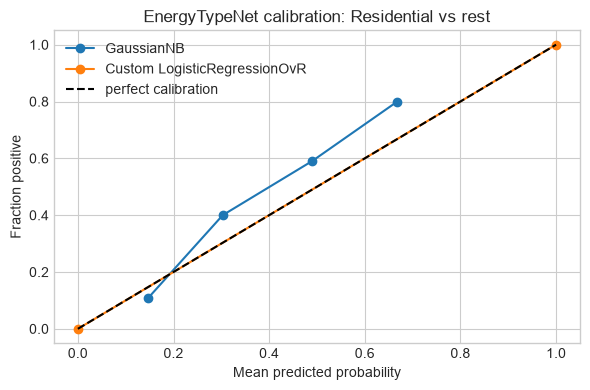

In [12]:
y_train_binary = (train_df['Building Type'] == 'Residential').astype(int).to_numpy()
y_test_binary = (test_df['Building Type'] == 'Residential').astype(int).to_numpy()

comparisons = []
start = time.perf_counter()
gnb_binary = GaussianNaiveBayes().fit(X_train, y_train_binary)
gnb_time = time.perf_counter() - start
gnb_prob = gnb_binary.predict_proba(X_test)[:, 1]
comparisons.append({'dataset': 'EnergyTypeNet', 'model': 'GaussianNB', 'accuracy': accuracy_score(y_test_binary, gnb_binary.predict(X_test)), 'train_seconds': gnb_time})

X_train_s = StandardScaler().fit_transform(X_train)
X_test_s = StandardScaler().fit(X_train).transform(X_test)
start = time.perf_counter()
lr_binary = LogisticRegressionOvR(eta=0.05, n_iter=1000, alpha=0.001).fit(X_train_s, y_train_binary)
lr_time = time.perf_counter() - start
lr_prob = lr_binary.predict_proba(X_test_s)[:, 1]
comparisons.append({'dataset': 'EnergyTypeNet', 'model': 'Custom LogisticRegressionOvR', 'accuracy': accuracy_score(y_test_binary, lr_binary.predict(X_test_s)), 'train_seconds': lr_time})

fig, ax = plt.subplots(figsize=(6, 4))
for label, prob in [('GaussianNB', gnb_prob), ('Custom LogisticRegressionOvR', lr_prob)]:
    frac_pos, mean_pred = calibration_curve(y_test_binary, prob, n_bins=5, strategy='uniform')
    ax.plot(mean_pred, frac_pos, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction positive')
ax.legend()
ax.set_title('EnergyTypeNet calibration: Residential vs rest')
plt.tight_layout()

if newsgroups_available:
    start = time.perf_counter()
    mnb_text = MultinomialNaiveBayes().fit(X_news_train, y_news_train)
    mnb_time = time.perf_counter() - start
    start = time.perf_counter()
    lr_text = LogisticRegression(max_iter=1000).fit(X_news_train, y_news_train)
    lr_text_time = time.perf_counter() - start
    comparisons.extend([
        {'dataset': '20 Newsgroups', 'model': 'MultinomialNB', 'accuracy': accuracy_score(y_news_test, mnb_text.predict(X_news_test)), 'train_seconds': mnb_time},
        {'dataset': '20 Newsgroups', 'model': 'sklearn LogisticRegression', 'accuracy': accuracy_score(y_news_test, lr_text.predict(X_news_test)), 'train_seconds': lr_text_time},
    ])

comparison_df = pd.DataFrame(comparisons)
comparison_df

## 9. Summary Table

The table below collects the completed probabilistic experiments. Supplementary rows appear only when their sklearn datasets are available locally.

**Observations:**
- Gaussian Naive Bayes performs weakly on the full EnergyTypeNet classification task because the class distributions overlap and several numeric features are correlated, especially Energy Consumption and Square Footage.
- The low Naive Bayes score is useful diagnostically: it shows that simple class-conditional Gaussian assumptions are not enough for this dataset.
- Bernoulli and Multinomial Naive Bayes are included to demonstrate when different likelihood models are appropriate, not because they are expected to beat the strongest discriminative classifiers here.
- Bayesian Linear Regression is useful for uncertainty-aware regression, especially when predictions should include a confidence interval rather than only a point estimate.


In [13]:
summary_rows = [
    {'model': 'GaussianNaiveBayes', 'dataset': 'EnergyTypeNet', 'metric': 'accuracy', 'score': custom_acc, 'custom_or_sklearn': 'custom', 'notes': 'continuous numeric features'},
    {'model': 'BernoulliNaiveBayes', 'dataset': 'EnergyTypeNet binarized', 'metric': 'accuracy', 'score': float(bnb_results.iloc[0]['accuracy']), 'custom_or_sklearn': 'custom', 'notes': 'median-thresholded features'},
    {'model': 'BayesianLinearRegression', 'dataset': 'EnergyTypeNet', 'metric': 'R2', 'score': float(energy_blr_results.iloc[0]['r2']), 'custom_or_sklearn': 'custom', 'notes': 'predictive mean and variance'},
]
if newsgroups_available:
    summary_rows.append({'model': 'MultinomialNaiveBayes', 'dataset': '20 Newsgroups', 'metric': 'accuracy', 'score': custom_news_acc, 'custom_or_sklearn': 'custom', 'notes': 'count-vectorized text'})
if california_available:
    best_ca = ca_results.sort_values('r2', ascending=False).iloc[0]
    summary_rows.append({'model': 'BayesianLinearRegression', 'dataset': 'California Housing', 'metric': 'R2', 'score': float(best_ca['r2']), 'custom_or_sklearn': 'custom', 'notes': 'optional cached sklearn dataset'})
summary_rows.extend(comparison_df.to_dict('records'))

pd.DataFrame(summary_rows)

,model,dataset,metric,score,custom_or_sklearn,notes,accuracy,train_seconds
0,GaussianNaiveBayes,EnergyTypeNet,accuracy,0.420000,custom,continuous numeric features,NaN,NaN
1,BernoulliNaiveBayes,EnergyTypeNet binarized,accuracy,0.470000,custom,median-thresholded features,NaN,NaN
2,BayesianLinearRegression,EnergyTypeNet,R2,0.731029,custom,predictive mean and variance,NaN,NaN
3,GaussianNB,EnergyTypeNet,NaN,NaN,NaN,NaN,0.7,0.000736
4,Custom LogisticRegressionOvR,EnergyTypeNet,NaN,NaN,NaN,NaN,1.0,0.174679
